# Exercise 4: Automatic Conformance Checking with PM4Py

API Documentation: https://processintelligence.solutions/pm4py/api?page=api.html  
API or methods may have changed.   

Import the Petri net "petri_new.pnml".

In [2]:
from pm4py.objects.petri_net.importer import importer as pnml_importer
net, im, fm = pnml_importer.apply("petri_new.pnml")

Load the event log "reviewing.xes".

In [3]:
from pm4py.objects.log.importer.xes import importer as xes_import_factory
log = xes_import_factory.apply("reviewing.xes")

C:\Users\baldauf\PycharmProjects\process-mining\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 100/100 [00:00<00:00, 977.18it/s]


Visualize the Petri Net.

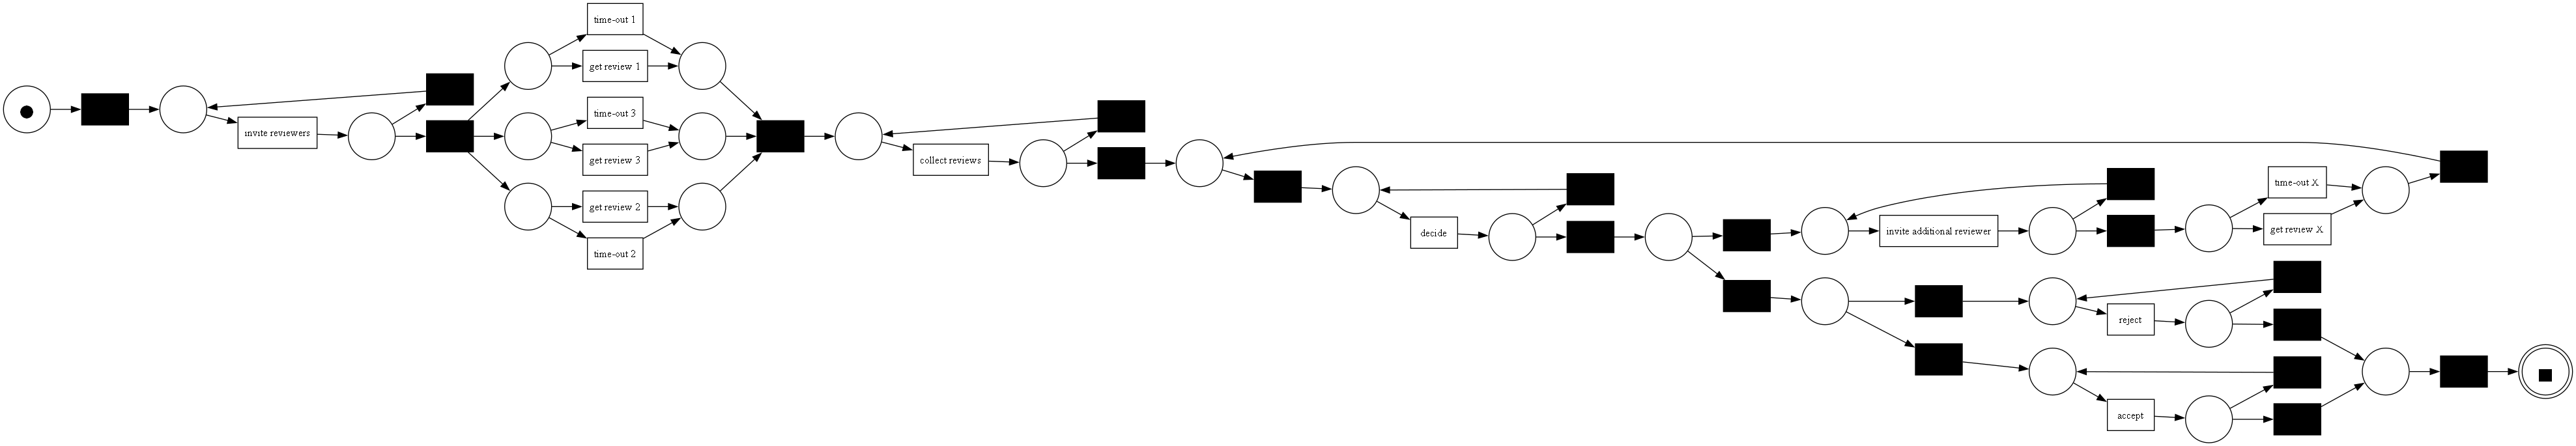

In [4]:
from pm4py.visualization.petri_net import visualizer as pn_vis_factory
viz = pn_vis_factory.apply(net, im, fm)
pn_vis_factory.view(viz)

What does the process represent? What is it about?

Analyse the event log and its attributes

We recommend to first convert the log into a pandas Dataframe for analysis

In [5]:
from pm4py.objects.conversion.log import converter
import pandas as pd

pd.set_option('display.max_columns', 5)
pd.set_option('display.width', 1100)
pd.set_option('display.max_rows', 50)

df_log = converter.apply(log, variant=converter.Variants.TO_DATA_FRAME)
print(df_log)

     org:resource            time:timestamp  ... accepts Result by Reviewer X
0            Mike 2006-01-01 00:00:00+00:00  ...     NaN                  NaN
1            Mike 2006-01-06 00:00:00+00:00  ...     NaN                  NaN
2           Carol 2006-01-09 00:00:00+00:00  ...     NaN                  NaN
3             Pam 2006-01-10 00:00:00+00:00  ...     NaN                  NaN
4            John 2006-01-11 00:00:00+00:00  ...     NaN                  NaN
...           ...                       ...  ...     ...                  ...
3718         Mary 2009-01-30 00:00:00+00:00  ...     NaN               accept
3719          Wil 2009-02-05 00:00:00+00:00  ...     NaN                  NaN
3720          Wil 2009-02-06 00:00:00+00:00  ...       3                  NaN
3721         Anne 2009-02-08 00:00:00+00:00  ...     NaN                  NaN
3722         Anne 2009-02-12 00:00:00+00:00  ...     NaN                  NaN

[3723 rows x 12 columns]


Finally, perform a token-based replay.
Analyse and interpret the results.

### Note: The result of the token-based replay is a list of variables for each case in the event log.
You can look up their meaning from the PM4Py homepage

In [6]:
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay

replay_result = token_replay.apply(log, net, im, fm)
df_replay = pd.DataFrame(replay_result)
print(df_replay.head())

replaying log with TBR, completed traces :: 100%|██████████| 96/96 [00:00<00:00, 323.45it/s]


   trace_is_fit  trace_fitness  ... remaining_tokens produced_tokens
0          True       1.000000  ...                0              64
1         False       0.978834  ...                1              93
2          True       1.000000  ...                0              88
3         False       0.981734  ...                3             110
4          True       1.000000  ...                0             100

[5 rows x 10 columns]


### Diagnosis

In [13]:
parameters = {token_replay.Variants.TOKEN_REPLAY.value.Parameters.DISABLE_VARIANTS: True,
                token_replay.Variants.TOKEN_REPLAY.value.Parameters.ENABLE_PLTR_FITNESS: True}

replayed_traces, place_fitness, trans_fitness, unwanted_activities = token_replay.apply(log, net, im , fm, parameters)

problem_traces = []
for idx, tr in enumerate(replayed_traces):
    if tr["trace_fitness"] < 1.0:
        problem_traces.append((idx, tr))

for idx, tr in enumerate(replayed_traces):
    if tr["trace_fitness"] < 1.0:
        print("\nTrace:", idx)
        print("  Fitness:", tr["trace_fitness"])
        print("  Missing Tokens:", tr.get("missing_tokens"))
        print("  Remaining Tokens:", tr.get("remaining_tokens"))
        print("  Problematic Transactions:", tr.get("transitions_with_problems"))

replaying log with TBR, completed traces :: 100%|██████████| 100/100 [00:02<00:00, 43.30it/s]


Trace: 1
  Fitness: 0.9788341822297679
  Missing Tokens: 3
  Remaining Tokens: 1
  Problematic Transactions: [(20b20b8d-0e71-40ce-a8eb-c0f3fbdc99a2, 'get review 2'), (c815b41c-9046-45a5-91d8-9934c203df7c, 'get review 3'), (24106cd1-1aa1-418e-80a7-15b9ee444f81, 'time-out 1')]

Trace: 3
  Fitness: 0.9817340067340068
  Missing Tokens: 1
  Remaining Tokens: 3
  Problematic Transactions: [(a4e070fa-7dc5-4402-93b3-a644ecb4c1e6, 'collect reviews')]

Trace: 7
  Fitness: 0.9552238805970149
  Missing Tokens: 3
  Remaining Tokens: 3
  Problematic Transactions: [(24106cd1-1aa1-418e-80a7-15b9ee444f81, 'time-out 1'), (51af0f37-90de-48d5-9132-8cb1734828c5, 'time-out 2'), (a4e070fa-7dc5-4402-93b3-a644ecb4c1e6, 'collect reviews')]


### Analysis

In [8]:
pd_results = pd.DataFrame(replayed_traces)
print(pd_results.head(20))

    trace_is_fit  trace_fitness  ... remaining_tokens produced_tokens
0           True       1.000000  ...                0              64
1          False       0.978834  ...                1              93
2           True       1.000000  ...                0              88
3          False       0.981734  ...                3             110
4           True       1.000000  ...                0             100
5           True       1.000000  ...                0             136
6           True       1.000000  ...                0             218
7          False       0.955224  ...                3              67
8           True       1.000000  ...                0              88
9           True       1.000000  ...                0              76
10          True       1.000000  ...                0             100
11          True       1.000000  ...                0             112
12          True       1.000000  ...                0              76
13          True    

In [15]:
from pm4py.algo.evaluation.replay_fitness import algorithm as evaluator

fit = evaluator.apply(log, net, im, fm, variant=evaluator.Variants.TOKEN_BASED)
print("Log Fitness:", fit['log_fitness'])

replaying log with TBR, completed traces :: 100%|██████████| 96/96 [00:00<00:00, 267.32it/s]

Log Fitness: 0.9992300923889134
